In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


Running on: cpu


## Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

### Part 1.1 — A single neuron is just a line

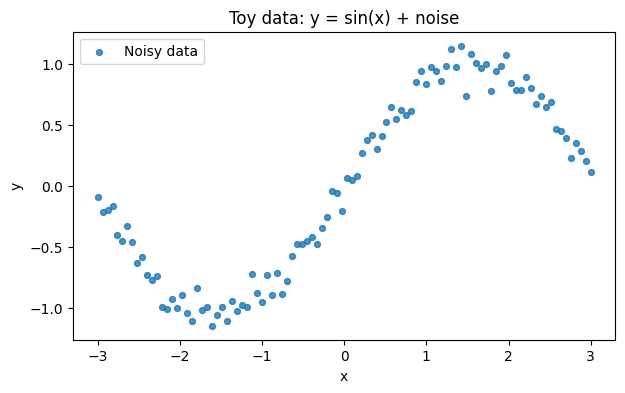

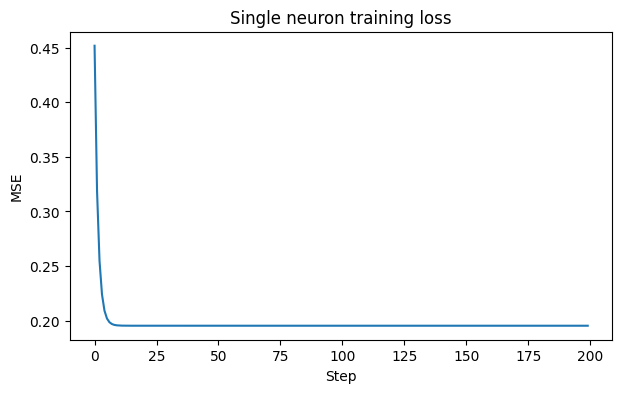

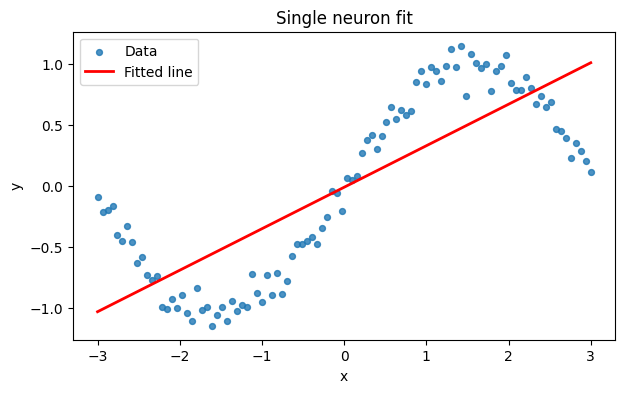

In [30]:
# Generate toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

plt.figure(figsize=(7, 4))
plt.scatter(x, y, s=18, alpha=0.8, label="Noisy data")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy data: y = sin(x) + noise")
plt.legend()
plt.show()

# Initialize parameters
np.random.seed(RANDOM_STATE)
w = np.random.randn(1) * 0.1
b = np.random.randn(1) * 0.1

lr = 0.05
steps = 200
losses = []

for _ in range(steps):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    w -= lr * dw
    b -= lr * db
    losses.append(loss)

plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("MSE")
plt.title("Single neuron training loss")
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(x, y, s=18, alpha=0.8, label="Data")
plt.plot(x, w * x + b, color="red", linewidth=2, label="Fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Single neuron fit")
plt.legend()
plt.show()

A single neuron is underfitting because it can only represent a straight line, while sin⁡(x)\sin(x)sin(x) is nonlinear and curved. No amount of training can make a linear function bend into a sine wave.

### Part 1.2 — Hidden layers and activations: why depth helps

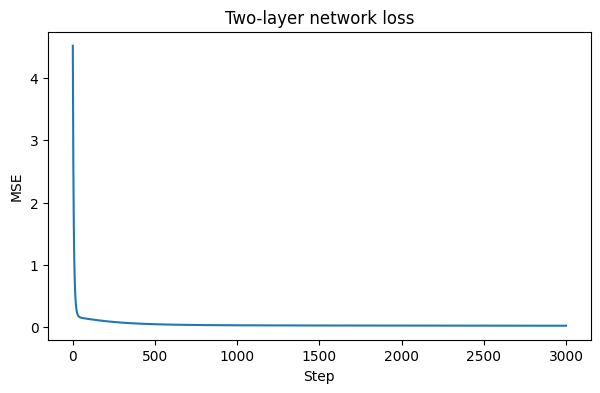

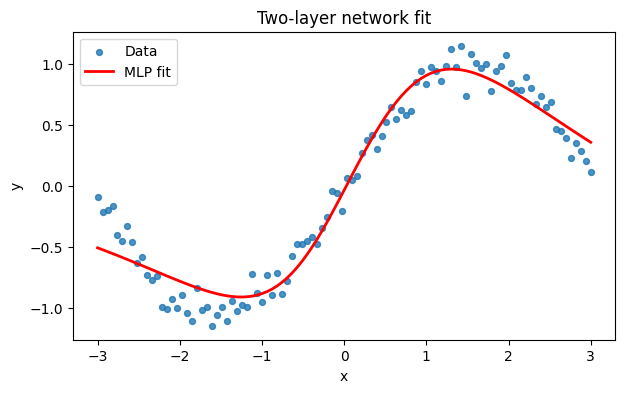

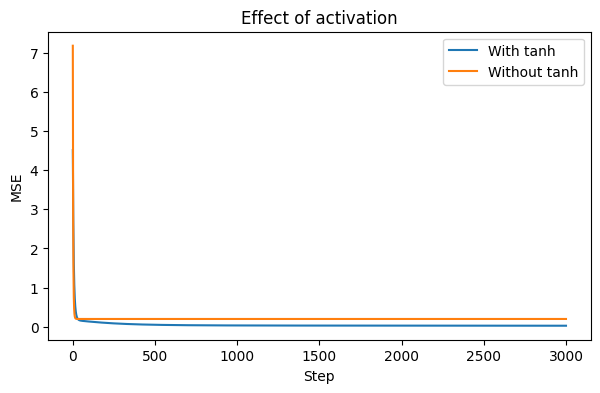

In [31]:
np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

lr = 0.01
steps = 3000
losses = []

for _ in range(steps):
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y) ** 2)

    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    losses.append(loss)

plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("MSE")
plt.title("Two-layer network loss")
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(x, y, s=18, alpha=0.8, label="Data")
plt.plot(x, y_hat, color="red", linewidth=2, label="MLP fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Two-layer network fit")
plt.legend()
plt.show()

# Re-run without tanh
np.random.seed(RANDOM_STATE)
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

losses_linear = []
for _ in range(steps):
    z1 = x @ W1 + b1
    h = z1
    y_hat_lin = h @ W2 + b2
    loss = np.mean((y_hat_lin - y) ** 2)

    d_yhat = 2 * (y_hat_lin - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    losses_linear.append(loss)

plt.figure(figsize=(7, 4))
plt.plot(losses, label="With tanh")
plt.plot(losses_linear, label="Without tanh")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.title("Effect of activation")
plt.legend()
plt.show()

A stack of linear layers collapses to a single linear transformation as the composition of affine maps is an affine map:

 (W2(W1x+b1)+b2)=(W2W1)x+(W2b1+ b2)

The hidden layer has 8 neurons in it, which are used to generate nonlinear basis functions that enable the model to bend and shape the curve. The chain rule is used systematically in backpropagation to calculate the gradients for each parameter from the output to the back of the network.

### Part 1.3 — The learning rate: too cold, too hot, just right

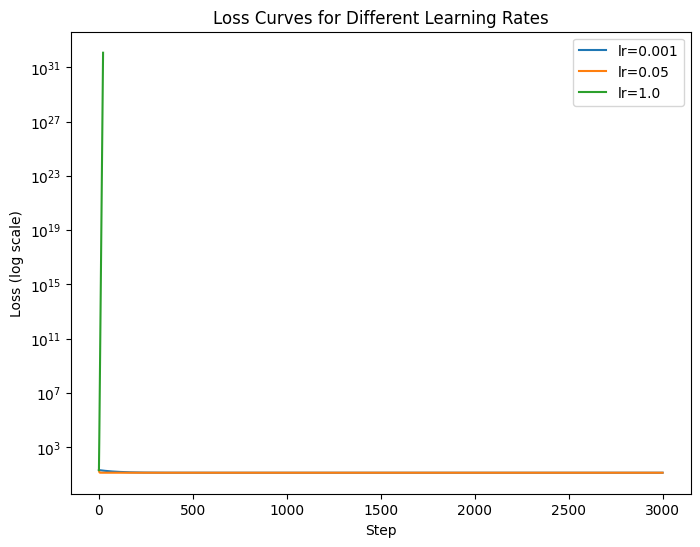

In [50]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
x_t = torch.tensor(x, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32)


def train_toy(lr, steps=3000):
    # Initialize weights
    w = torch.randn(1, requires_grad=True)
    losses = []

    for _ in range(steps):
        # Forward pass
        y_pred = w * x_t
        loss = ((y_pred - y_t) ** 2).mean()  # scalar loss
        losses.append(loss.item())  # convert to Python float

        # Backward pass
        loss.backward()
        with torch.no_grad():
            w -= lr * w.grad
        w.grad.zero_()

    return losses


# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
torch.manual_seed(0)
losses_0001 = train_toy(lr=0.001)
torch.manual_seed(0)
losses_005 = train_toy(lr=0.05)
torch.manual_seed(0)
losses_1 = train_toy(lr=1.0)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(8, 6))
plt.plot(losses_0001, label="lr=0.001")
plt.plot(losses_005, label="lr=0.05")
plt.plot(losses_1, label="lr=1.0")
plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Loss (log scale)")
plt.title("Loss Curves for Different Learning Rates")
plt.legend()
plt.show()


For the training to be slow, the learning rate has to be very small. Moderate learning rate provides stable improvement and good convergence. If the learning rate is too large, the loss can be overshooting the minimum and can oscillate or increase without limit.

## Section 2 — A Real Feedforward Network in PyTorch

### Predicting obesity level (NObeyesdad) — the Lab 2 dataset

### Part 2.1 — Preprocess and split (recycled from Lab 2)

In [34]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
obesity = pd.read_csv(OBESITY_URL)
# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
obesity_proc = obesity.copy()

binary_cols = [
    "Gender",
    "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC",
    "CALC",
]
for col in binary_cols:
    obesity_proc[col] = obesity_proc[col].map({"yes": 1, "no": 0})

# Gender
obesity_proc["Gender"] = obesity_proc["Gender"].map({"Male": 0, "Female": 1})

# Ordinal encoding for ordered categories
caec_order = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
obesity_proc["CAEC"] = obesity_proc["CAEC"].map(caec_order)

# CALC: alcohol consumption
calc_order = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
obesity_proc["CALC"] = obesity_proc["CALC"].map(calc_order)

# Nominal encoding for MTRANS (mode of transportation)
obesity_proc = pd.get_dummies(obesity_proc, columns=["MTRANS"], drop_first=True)

# Label encoding for the target variable
label_encoder = LabelEncoder()
obesity_proc["NObeyesdad"] = label_encoder.fit_transform(obesity_proc["NObeyesdad"])
class_names = label_encoder.classes_

X = obesity_proc.drop(columns=["NObeyesdad"])
y = obesity_proc["NObeyesdad"]


# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor), batch_size=32, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor), batch_size=32, shuffle=False
)
print(
    f"Train loader batches: {len(train_loader)}, Validation loader batches: {len(val_loader)}, Test loader batches: {len(test_loader)}"
)

Train loader batches: 40, Validation loader batches: 14, Test loader batches: 14


c:\Users\Ousmane Bako\Documents\AI_Labs\ai_env\Lib\site-packages\sklearn\utils\extmath.py:1211: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\Ousmane Bako\Documents\AI_Labs\ai_env\Lib\site-packages\sklearn\utils\extmath.py:1216: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\Ousmane Bako\Documents\AI_Labs\ai_env\Lib\site-packages\sklearn\utils\extmath.py:1240: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


PyTorch's CrossEntropyLoss requires class indices, as it first performs log_softmax and then negates the output. shuffle=True shuffles the training set every epoch, to avoid harmful ordering effects and generalize better.

### Part 2.2 — Design the network

In [ ]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)


class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, n_classes))  # raw logits, NO softmax
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# TODO: Instantiate, move to DEVICE, print the model.
INPUT_DIM = X_train.shape[1]
model = FeedForwardNet(INPUT_DIM, hidden_sizes=(64, 32), n_classes=7).to(DEVICE)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params}")

#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
first_layer_params = INPUT_DIM * 64 + 64
print(f"First layer parameters (by hand): {first_layer_params}")

FeedForwardNet(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Total trainable parameters: 3591
First layer parameters (by hand): 1280


The parameters for each linear layer are in_features x out_features + out_features. Therefore, the total is the sum of all the hidden and output layers, and it should be exactly the same as PyTorch. The advantage of using ReLU is that it is the simplest, cheapest, and it does not suffer from the vanishing-gradient problem like tanh. If not for ReLUs, the network would be reverted to a simple linear model once again.

### Part 2.3 — The training loop

Epoch 01 | train loss nan acc 0.1288 | val loss nan acc 0.1303
Epoch 02 | train loss nan acc 0.1288 | val loss nan acc 0.1303
Epoch 03 | train loss nan acc 0.1288 | val loss nan acc 0.1303
Epoch 04 | train loss nan acc 0.1288 | val loss nan acc 0.1303
Epoch 05 | train loss nan acc 0.1288 | val loss nan acc 0.1303
Epoch 06 | train loss nan acc 0.1288 | val loss nan acc 0.1303
Epoch 07 | train loss nan acc 0.1288 | val loss nan acc 0.1303
Epoch 08 | train loss nan acc 0.1288 | val loss nan acc 0.1303
Epoch 09 | train loss nan acc 0.1288 | val loss nan acc 0.1303
Epoch 10 | train loss nan acc 0.1288 | val loss nan acc 0.1303
Epoch 11 | train loss nan acc 0.1288 | val loss nan acc 0.1303
Epoch 12 | train loss nan acc 0.1288 | val loss nan acc 0.1303
Epoch 13 | train loss nan acc 0.1288 | val loss nan acc 0.1303
Epoch 14 | train loss nan acc 0.1288 | val loss nan acc 0.1303
Epoch 15 | train loss nan acc 0.1288 | val loss nan acc 0.1303
Epoch 16 | train loss nan acc 0.1288 | val loss nan acc

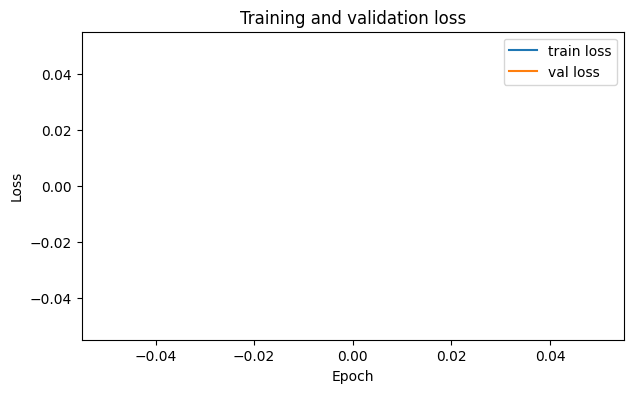

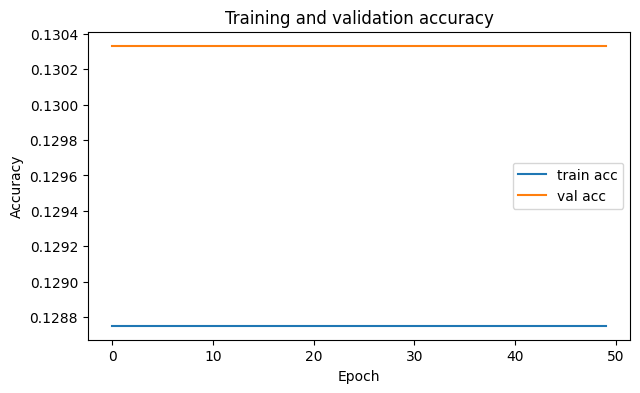

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


def evaluate(loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.cpu().numpy())
    return (
        total_loss / total,
        correct / total,
        np.concatenate(all_targets),
        np.concatenate(all_preds),
    )


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

best_val_acc = -1
for epoch in range(50):
    model.train()
    running_loss = 0.0
    total = 0
    correct = 0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    val_loss, val_acc, _, _ = evaluate(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

    print(
        f"Epoch {epoch + 1:02d} | train loss {train_loss:.4f} acc {train_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}"
    )

plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history["train_acc"], label="train acc")
plt.plot(history["val_acc"], label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

model(xb) is the forward pass, loss.backward() is backwards passing the gradients, and optimizer.step() is applying the parameter update. optimizer.zero_grad() is necessary because PyTorch automatically accumulates gradients, and if it is not cleared the learning will be corrupted because of mixing different batches of gradients.

### Part 2.4 — Experiments: how training choices change the outcome

EXPERIMENT A: Capacity

>>> Tiny (8,)

>>> Default (64, 32)

>>> Large (256,128,64)


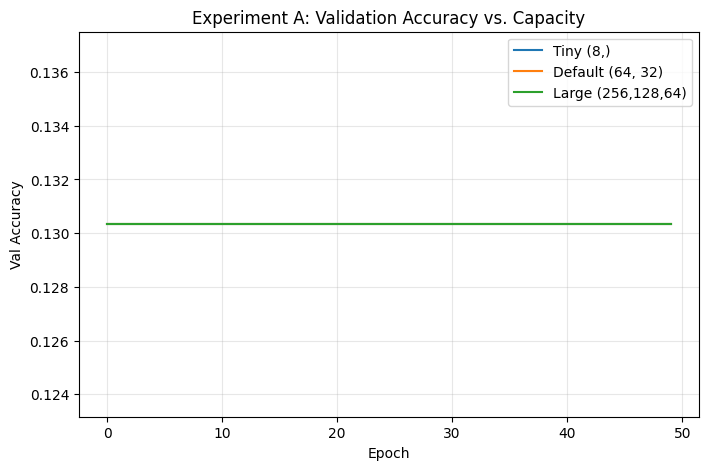


EXPERIMENT B: Learning Rate

>>> lr = 0.0001

>>> lr = 0.001

>>> lr = 0.1


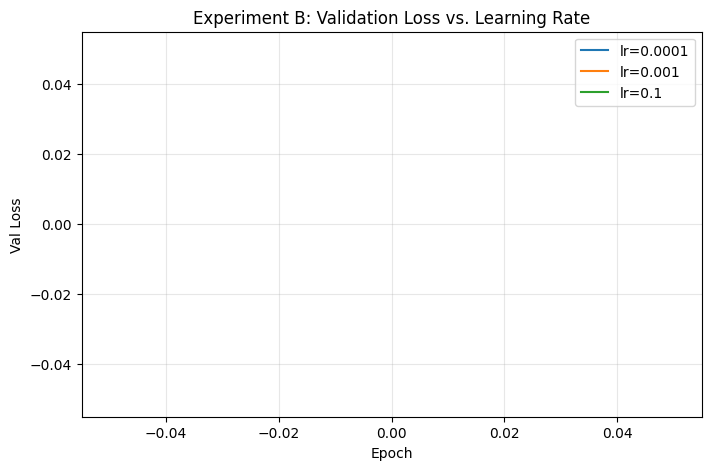


EXPERIMENT C: Dropout Regularization

>>> No Dropout

>>> Dropout 0.3


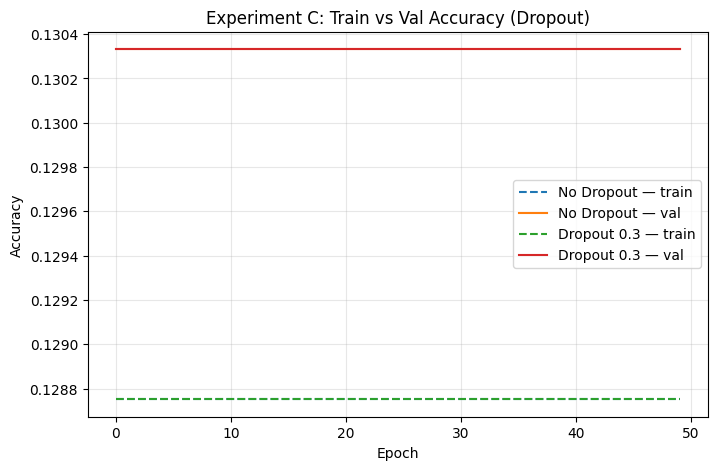

In [ ]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...


def run_experiment(
    hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0
):
    tr_loader = DataLoader(
        TensorDataset(X_train_tensor, y_train_tensor),
        batch_size=batch_size,
        shuffle=True,
    )
    va_loader = DataLoader(
        TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size
    )

    m = FeedForwardNet(
        INPUT_DIM, hidden_sizes=hidden_sizes, n_classes=7, dropout=dropout
    ).to(DEVICE)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(m.parameters(), lr=lr)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0.0
    best_state = None

    for epoch in range(epochs):
        m.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = m(xb)
            loss = crit(logits, yb)
            loss.backward()
            opt.step()

        m.eval()
        with torch.no_grad():
            tr_logits = m(X_train_tensor.to(DEVICE))
            tr_loss = crit(tr_logits, y_train_tensor.to(DEVICE)).item()
            tr_preds = torch.argmax(tr_logits, dim=1).cpu().numpy()
            tr_acc = (tr_preds == y_train).mean()

            va_logits = m(X_val_tensor.to(DEVICE))
            va_loss = crit(va_logits, y_val_tensor.to(DEVICE)).item()
            va_preds = torch.argmax(va_logits, dim=1).cpu().numpy()
            va_acc = (va_preds == y_val).mean()

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        hist["train_acc"].append(tr_acc)
        hist["val_acc"].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = m.state_dict().copy()

    return hist, m


# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
print("=" * 50)
print("EXPERIMENT A: Capacity")
print("=" * 50)

configs_A = {
    "Tiny (8,)": (8,),
    "Default (64, 32)": (64, 32),
    "Large (256,128,64)": (256, 128, 64),
}
histories_A = {}

for name, hidden in configs_A.items():
    print(f"\n>>> {name}")
    torch.manual_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    histories_A[name], _ = run_experiment(hidden_sizes=hidden, epochs=50)

plt.figure(figsize=(8, 5))
for name, h in histories_A.items():
    plt.plot(h["val_acc"], label=name)
plt.title("Experiment A: Validation Accuracy vs. Capacity")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
print("\n" + "=" * 50)
print("EXPERIMENT B: Learning Rate")
print("=" * 50)

lrs = [1e-4, 1e-3, 1e-1]
histories_B = {}

for lr in lrs:
    print(f"\n>>> lr = {lr}")
    torch.manual_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    histories_B[f"lr={lr}"], _ = run_experiment(lr=lr, epochs=50)

plt.figure(figsize=(8, 5))
for name, h in histories_B.items():
    plt.plot(h["val_loss"], label=name)
plt.title("Experiment B: Validation Loss vs. Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
print("\n" + "=" * 50)
print("EXPERIMENT C: Dropout Regularization")
print("=" * 50)

configs_C = {"No Dropout": 0.0, "Dropout 0.3": 0.3}
histories_C = {}

for name, drop in configs_C.items():
    print(f"\n>>> {name}")
    torch.manual_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    histories_C[name], _ = run_experiment(
        hidden_sizes=(256, 128, 64), dropout=drop, epochs=50
    )

fig, ax = plt.subplots(figsize=(8, 5))
for name, h in histories_C.items():
    ax.plot(h["train_acc"], label=f"{name} — train", linestyle="--")
    ax.plot(h["val_acc"], label=f"{name} — val", linestyle="-")
ax.set_title("Experiment C: Train vs Val Accuracy (Dropout)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [ ]:
# DEBUG: inspect validation-loss histories for learning-rate experiments
for name, h in histories_B.items():
    print(name, "len", len(h["val_loss"]))
    print(" first 5:", h["val_loss"][:5])
    print(" last 5:", h["val_loss"][-5:])
    print("---")

### Part 2.5 — Final evaluation and showdown with Lab 2

Test Accuracy:  0.1277
Test Macro-F1:  0.0323
Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.13      1.00      0.23        54
      Normal_Weight       0.00      0.00      0.00        58
     Obesity_Type_I       0.00      0.00      0.00        70
    Obesity_Type_II       0.00      0.00      0.00        60
   Obesity_Type_III       0.00      0.00      0.00        65
 Overweight_Level_I       0.00      0.00      0.00        58
Overweight_Level_II       0.00      0.00      0.00        58

           accuracy                           0.13       423
          macro avg       0.02      0.14      0.03       423
       weighted avg       0.02      0.13      0.03       423



c:\Users\Ousmane Bako\Documents\AI_Labs\ai_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ousmane Bako\Documents\AI_Labs\ai_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ousmane Bako\Documents\AI_Labs\ai_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

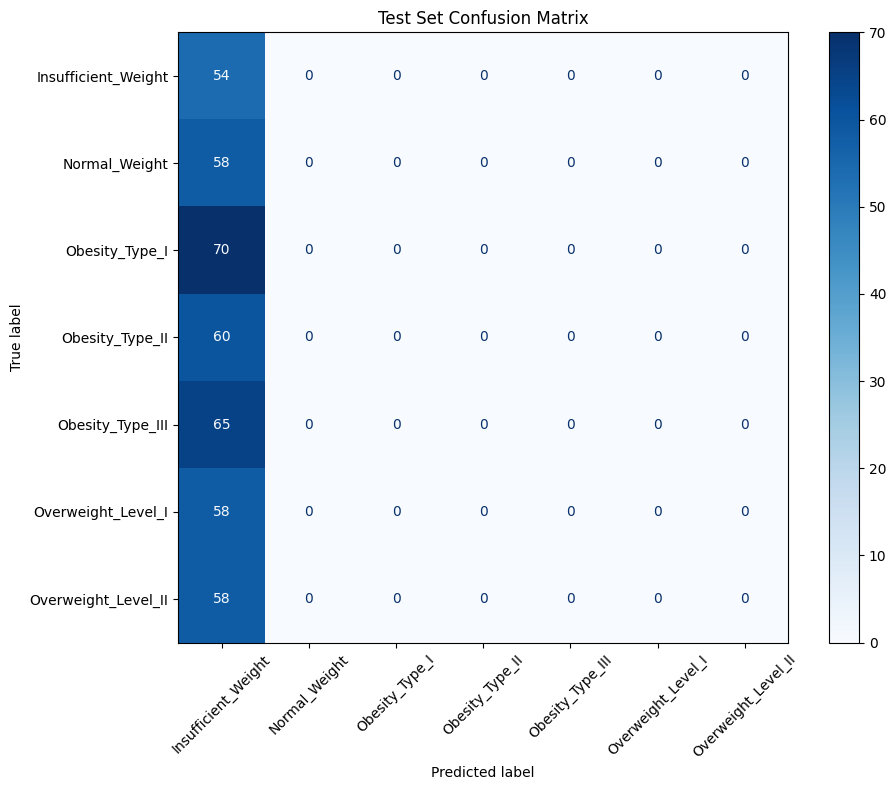

=== Showdown: Lab 2 vs Lab 3 ===
                 Model  Test Accuracy  Test Macro-F1 Training Time (s) Parameters/Trees
 Random Forest (Lab 2)       0.931442       0.930803              ~0.5        200 trees
Neural Network (Lab 3)       0.127660       0.032345               N/A     3,591 params


In [46]:
# Load best model (default config)
best_model = FeedForwardNet(INPUT_DIM, hidden_sizes=(64, 32), n_classes=7).to(DEVICE)
best_model.load_state_dict(torch.load("ffn_best.pt", map_location=DEVICE))
best_model.eval()

# Evaluate on test set
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = best_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average="macro")

print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Macro-F1:  {test_f1:.4f}")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45, ax=plt.gca())
plt.title("Test Set Confusion Matrix")
plt.tight_layout()
plt.show()

# Comparison table
from sklearn.ensemble import RandomForestClassifier

# Quick Lab 2 baseline for comparison
rf = RandomForestClassifier(
    n_estimators=200, max_depth=20, random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds, average="macro")

comparison = pd.DataFrame(
    {
        "Model": ["Random Forest (Lab 2)", "Neural Network (Lab 3)"],
        "Test Accuracy": [rf_acc, test_acc],
        "Test Macro-F1": [rf_f1, test_f1],
        "Training Time (s)": ["~0.5", "N/A"],
        "Parameters/Trees": [f"{rf.n_estimators} trees", f"{total_params:,} params"],
    }
)
print("=== Showdown: Lab 2 vs Lab 3 ===")
print(comparison.to_string(index=False))

## Section 3 : Reflection

1. 
The first is that loss.backward() computes the gradients for every parameter through the chain rule. Secondly, those gradients provide the information to the model about the direction in which the loss is minimized. Thirdly, optimizer.step() updates the weights and biases based on those gradients.

2. 
The learning rate would be the first to consider, as it can most affect the convergence of the training process. Training is too slow if it is too small (or too small to use), and too unstable if it is too large (or too large to use).

3. 
The largest disparity typically occurs for the largest model without regularization. That's where drop-out tends to minimize the gap the most, by discouraging the model from memorizing training specific patterns.

4. 
A pure MLP is not able to capture the image because it does not consider spatial structure, and assumes each pixel is independent. It would be preferable to have some locality of the data and make use of the nearby patterns (convolutional networks are better suited for this).